In [1]:
import tensorflow as tf
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

2026-04-13 20:41:26.952995: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 20:41:27.009302: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 20:41:27.296085: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/drivex/Ali/waymo_env/lib/python3.10/site-packages/nvidia/cudnn/lib:/home/drivex/Ali/waymo_en

Num GPUs Available: 1


2026-04-13 20:41:27.692399: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-13 20:41:27.709433: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-13 20:41:27.711609: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [ ]:
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

FILE_PATH = 'validation.tfrecord-00000-of-00150'

# Create the dataset object
dataset = tf.data.TFRecordDataset(FILE_PATH)

# Unpack the first scenario
for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
print(f"✅ Scenario {scenario.scenario_id} loaded successfully!")
print(f"✅ Found {len(scenario.map_features)} map features and {len(scenario.tracks)} agents.")

2026-03-28 13:41:10.122347: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-28 13:41:10.174112: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 13:41:10.175963: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-28 13:41:10.175971: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudar

✅ Scenario b85e1bd6cc8e74c0 loaded successfully!
✅ Found 139 map features and 14 agents.


2026-03-28 13:41:10.871508: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-28 13:41:10.872523: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-28 13:41:10.872544: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-03-28 13:41:10.872560: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-03-28 13:41:10.872576: W tensorflow/c

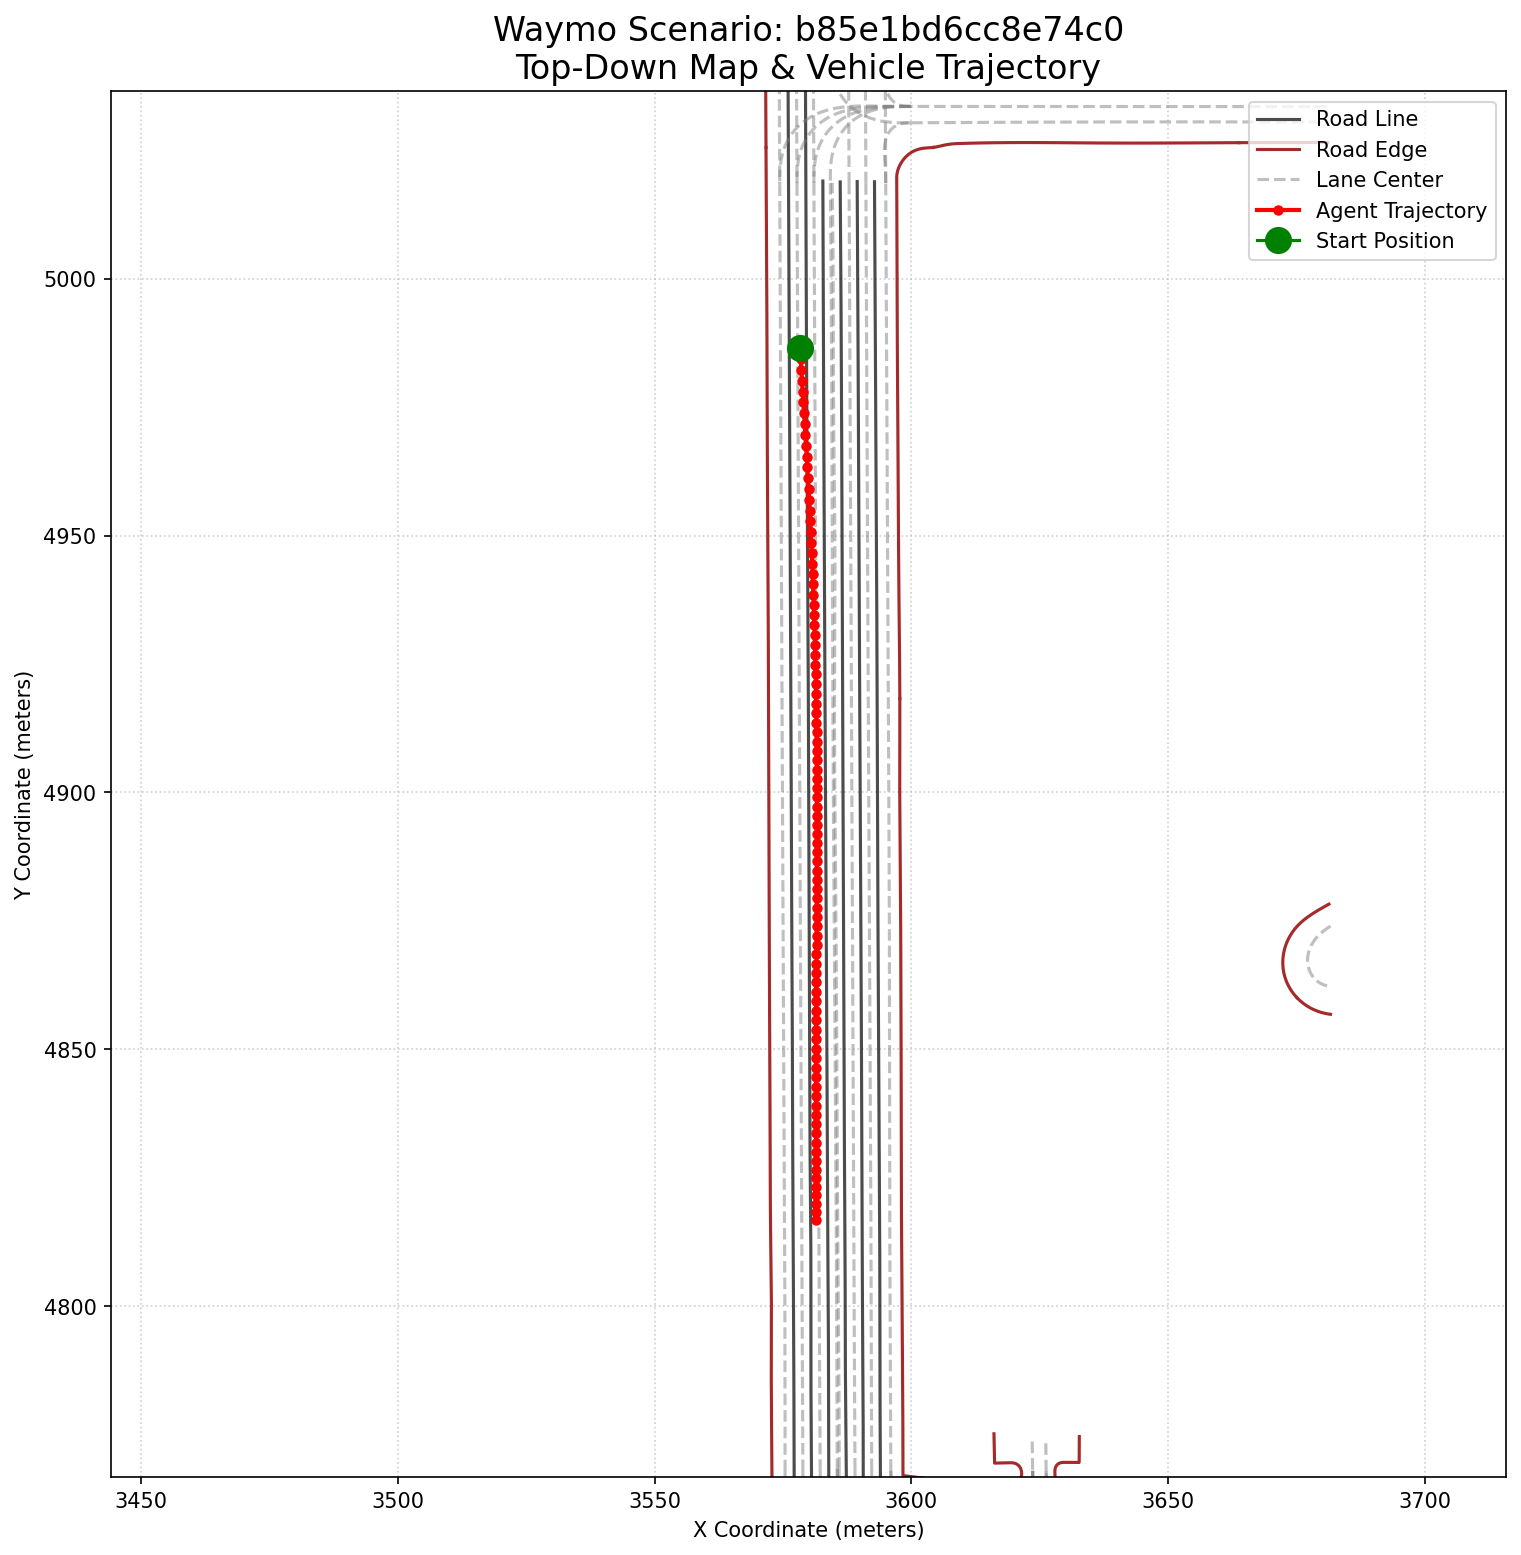

In [ ]:
import matplotlib
matplotlib.use('Agg') # This forcefully blocks Jupyter from using its buggy renderer!
import matplotlib.pyplot as plt

from IPython.display import Image, display

# Set up the canvas
plt.figure(figsize=(12, 12))
plt.title(f"Waymo Scenario: {scenario.scenario_id}\nTop-Down Map & Vehicle Trajectory", fontsize=16)

labels_added = {'lane': False, 'road_line': False, 'road_edge': False, 'crosswalk': False}

# Draw the Map
for feature in scenario.map_features:
    feature_type = feature.WhichOneof("feature_data")
    
    if feature_type == 'lane':
        pts = feature.lane.polyline
        style, color, alpha, label_name = '--', 'gray', 0.5, 'Lane Center'
    elif feature_type == 'road_line':
        pts = feature.road_line.polyline
        style, color, alpha, label_name = '-', 'black', 0.7, 'Road Line'
    elif feature_type == 'road_edge':
        pts = feature.road_edge.polyline
        style, color, alpha, label_name = '-', 'brown', 1.0, 'Road Edge'
    elif feature_type == 'crosswalk':
        pts = feature.crosswalk.polygon
        style, color, alpha, label_name = '-', 'blue', 0.4, 'Crosswalk'
    else:
        continue 
        
    if len(pts) > 0:
        x = [p.x for p in pts]
        y = [p.y for p in pts]
        
        label = label_name if not labels_added[feature_type] else ""
        labels_added[feature_type] = True
        plt.plot(x, y, linestyle=style, color=color, alpha=alpha, label=label, linewidth=1.5)

# Draw the Vehicle's Path
first_agent = scenario.tracks[0]
agent_x = [state.center_x for state in first_agent.states if state.valid]
agent_y = [state.center_y for state in first_agent.states if state.valid]

if len(agent_x) > 0:
    plt.plot(agent_x, agent_y, color='red', marker='.', linestyle='-', linewidth=2, markersize=8, label='Agent Trajectory')
    plt.plot(agent_x[0], agent_y[0], color='green', marker='o', markersize=12, label='Start Position')

# Format the dimensions perfectly
plt.axis('equal') 
plt.xlabel("X Coordinate (meters)")
plt.ylabel("Y Coordinate (meters)")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Zoom in around the vehicle
plt.xlim(min(agent_x) - 50, max(agent_x) + 50)
plt.ylim(min(agent_y) - 50, max(agent_y) + 50)

# SAVE THE IMAGE AND DISPLAY IT / Bypasses Jupyter bugs
plt.savefig('waymo_map.png', dpi=150, bbox_inches='tight')
plt.close() # Close the invisible buggy window

display(Image('waymo_map.png'))

In [ ]:
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

FILE_PATH = 'validation.tfrecord-00000-of-00150'

# dataset object
dataset = tf.data.TFRecordDataset(FILE_PATH)

# Grab just the FIRST scenario from the file
for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    print("🎉 SUCCESS! Scenario unpacked.\n")
    print(f"Scenario ID: {scenario.scenario_id}")
    print(f"Total time steps: {len(scenario.timestamps_seconds)} (91 steps = 9 seconds at 10Hz)")
    print(f"Number of agents (tracks) in this scene: {len(scenario.tracks)}")
    
    # --- Let's look at the first agent's trajectory! ---
    first_agent = scenario.tracks[0]
    print(f"\n--- First Agent Info ---")
    print(f"ID: {first_agent.id}")
    print(f"Type: {first_agent.object_type} (1=Vehicle, 2=Pedestrian, 3=Cyclist)") 
    
    # Print the first 5 X/Y coordinates of this agent
    print("\nFirst 5 X,Y coordinates of this agent:")
    for i in range(5):
        state = first_agent.states[i]
        # Waymo marks invalid states (e.g., if a car is occluded) with valid=False
        if state.valid:
            print(f"Time Step {i}: X = {state.center_x:.2f}, Y = {state.center_y:.2f}, Speed = {state.velocity_x:.2f} m/s")
        else:
            print(f"Time Step {i}: [Agent not visible in this frame]")




# --- Let's explore the static map (The "Polylines") ---
    print(f"\n--- Map Features (Polylines) ---")
    print(f"Total map features (lanes, crosswalks, stop signs) in this scene: {len(scenario.map_features)}")
    
    # Let's look at the first 3 map features to see how the road is built
    for i in range(3):
        feature = scenario.map_features[i]
        
        # This tells us if it's a lane, a crosswalk, a road edge, etc.
        feature_type = feature.WhichOneof("feature_data")
        print(f"\nFeature {i}: Type = {feature_type}")
        
        # If the feature is a lane, let's extract its mathematical shape
        if feature_type == 'lane':
            lane_polyline = feature.lane.polyline
            print(f"  This lane is made of {len(lane_polyline)} mathematical points.")
            print(f"  Start coordinate: X = {lane_polyline[0].x:.2f}, Y = {lane_polyline[0].y:.2f}")
            print(f"  End coordinate:   X = {lane_polyline[-1].x:.2f}, Y = {lane_polyline[-1].y:.2f}")

🎉 SUCCESS! Scenario unpacked.

Scenario ID: b85e1bd6cc8e74c0
Total time steps: 91 (91 steps = 9 seconds at 10Hz)
Number of agents (tracks) in this scene: 14

--- First Agent Info ---
ID: 1807
Type: 1 (1=Vehicle, 2=Pedestrian, 3=Cyclist)

First 5 X,Y coordinates of this agent:
Time Step 0: X = 3578.35, Y = 4986.54, Speed = 1.09 m/s
Time Step 1: X = 3578.46, Y = 4984.41, Speed = 1.11 m/s
Time Step 2: X = 3578.58, Y = 4982.28, Speed = 1.24 m/s
Time Step 3: X = 3578.71, Y = 4980.16, Speed = 1.24 m/s
Time Step 4: X = 3578.83, Y = 4978.03, Speed = 1.27 m/s

--- Map Features (Polylines) ---
Total map features (lanes, crosswalks, stop signs) in this scene: 139

Feature 0: Type = road_line

Feature 1: Type = road_line

Feature 2: Type = road_line


In [ ]:
print(f"--- Map Features (Polylines) ---")
print(f"Total map features in this scene: {len(scenario.map_features)}")

# Let's look at the first 10 map features and extract their coordinates
for i in range(10):
    feature = scenario.map_features[i]
    feature_type = feature.WhichOneof("feature_data")
    
    print(f"\nFeature {i}: Type = {feature_type}")
    
    # Grab the polyline data based on what type of feature it is
    polyline = None
    if feature_type == 'lane':
        polyline = feature.lane.polyline
    elif feature_type == 'road_line':
        polyline = feature.road_line.polyline
    elif feature_type == 'road_edge':
        polyline = feature.road_edge.polyline
    elif feature_type == 'crosswalk':
        # Crosswalks use 'polygon' instead of 'polyline' in Waymo
        polyline = feature.crosswalk.polygon 
        
    # If we successfully grabbed the points, let's print the start and end!
    if polyline and len(polyline) > 0:
        print(f"  -> Made of {len(polyline)} mathematical points (nodes).")
        print(f"  -> Start coordinate: X = {polyline[0].x:.2f}, Y = {polyline[0].y:.2f}")
        print(f"  -> End coordinate:   X = {polyline[-1].x:.2f}, Y = {polyline[-1].y:.2f}")

--- Map Features (Polylines) ---
Total map features in this scene: 139

Feature 0: Type = road_line
  -> Made of 1133 mathematical points (nodes).
  -> Start coordinate: X = 3574.94, Y = 5287.56
  -> End coordinate:   X = 3577.38, Y = 4725.79

Feature 1: Type = road_line
  -> Made of 1134 mathematical points (nodes).
  -> Start coordinate: X = 3578.29, Y = 5287.75
  -> End coordinate:   X = 3580.80, Y = 4725.70

Feature 2: Type = road_line
  -> Made of 490 mathematical points (nodes).
  -> Start coordinate: X = 3585.07, Y = 5287.57
  -> End coordinate:   X = 3586.15, Y = 5044.85

Feature 3: Type = road_edge
  -> Made of 534 mathematical points (nodes).
  -> Start coordinate: X = 3570.62, Y = 5287.70
  -> End coordinate:   X = 3571.71, Y = 5025.54

Feature 4: Type = road_line
  -> Made of 489 mathematical points (nodes).
  -> Start coordinate: X = 3582.54, Y = 5044.88
  -> End coordinate:   X = 3581.61, Y = 5287.92

Feature 5: Type = road_line
  -> Made of 560 mathematical points (nodes

In [ ]:
import matplotlib.pyplot as plt

# 1. Set up a large, clear canvas
plt.figure(figsize=(12, 12))
plt.title(f"Waymo Scenario: {scenario.scenario_id}\nTop-Down Map & Vehicle Trajectory", fontsize=16)

# 2. Track labels so we don't clutter the legend
labels_added = {'lane': False, 'road_line': False, 'road_edge': False, 'crosswalk': False}

# 3. Plot the Map Features (The Environment)
for feature in scenario.map_features:
    feature_type = feature.WhichOneof("feature_data")
    
    # Extract the X and Y coordinates for the polyline/polygon
    if feature_type == 'lane':
        pts = feature.lane.polyline
        style, color, alpha, label_name = '--', 'gray', 0.5, 'Lane Center'
    elif feature_type == 'road_line':
        pts = feature.road_line.polyline
        style, color, alpha, label_name = '-', 'black', 0.7, 'Road Line'
    elif feature_type == 'road_edge':
        pts = feature.road_edge.polyline
        style, color, alpha, label_name = '-', 'brown', 1.0, 'Road Edge'
    elif feature_type == 'crosswalk':
        pts = feature.crosswalk.polygon
        style, color, alpha, label_name = '-', 'blue', 0.4, 'Crosswalk'
    else:
        continue # Skip other features for now
        
    if len(pts) > 0:
        x = [p.x for p in pts]
        y = [p.y for p in pts]
        
        # Only add the label to the legend the first time we see this type
        label = label_name if not labels_added[feature_type] else ""
        labels_added[feature_type] = True
        
        plt.plot(x, y, linestyle=style, color=color, alpha=alpha, label=label, linewidth=1.5)

# 4. Plot the First Agent's Trajectory
first_agent = scenario.tracks[0]
agent_x = []
agent_y = []

for state in first_agent.states:
    if state.valid: # Only grab valid coordinates
        agent_x.append(state.center_x)
        agent_y.append(state.center_y)

if len(agent_x) > 0:
    # Plot the full path in red
    plt.plot(agent_x, agent_y, color='red', marker='.', linestyle='-', linewidth=2, markersize=8, label='Agent Trajectory')
    # Mark the starting position with a big green dot
    plt.plot(agent_x[0], agent_y[0], color='green', marker='o', markersize=12, label='Agent Start Position')

# 5. Format the Plot for accuracy
plt.axis('equal') # CRITICAL: This ensures 1 meter in X looks the same as 1 meter in Y (no stretching!)
plt.xlabel("X Coordinate (meters)", fontsize=12)
plt.ylabel("Y Coordinate (meters)", fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Zoom in slightly around the vehicle to see the details better
plt.xlim(min(agent_x) - 50, max(agent_x) + 50)
plt.ylim(min(agent_y) - 50, max(agent_y) + 50)

# 6. Render the map!
# Save the plot as a high-res image directly to your server folder
plt.savefig('waymo_intersection.png', dpi=300, bbox_inches='tight')
plt.close() # Close the buggy plot window

# Force Jupyter to display the saved image file
from IPython.display import Image
Image('waymo_intersection.png')

In [1]:
import tensorflow as tf
import glob
import math
from waymo_open_dataset.protos import scenario_pb2

file_pattern = 'validation.tfrecord-*-of-00150'
file_paths = sorted(glob.glob(file_pattern))[:50] 

print(f"Found {len(file_paths)} files to analyze.")

dataset = tf.data.TFRecordDataset(file_paths)

total_scenarios_analyzed = 0
dangerous_interactions = 0

for data in dataset.take(200):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    total_scenarios_analyzed += 1
    
    sdc_index = scenario.sdc_track_index
    ego_vehicle = scenario.tracks[sdc_index]
    
    pedestrians = [track for track in scenario.tracks if track.object_type == 2] # 2 = Pedestrian
    
    interaction_found = False
    
    for step in range(len(scenario.timestamps_seconds)):
        
        ego_state = ego_vehicle.states[step]
        if not ego_state.valid:
            continue 
            
        ego_x, ego_y = ego_state.center_x, ego_state.center_y
        
        for ped in pedestrians:
            ped_state = ped.states[step]
            if not ped_state.valid:
                continue
                
            ped_x, ped_y = ped_state.center_x, ped_state.center_y
            
            distance = math.hypot(ego_x - ped_x, ego_y - ped_y)
            
            if distance < 5.0:
                interaction_found = True
                break 
                
        if interaction_found:
            dangerous_interactions += 1
            print(f"⚠️ Close interaction found in Scenario: {scenario.scenario_id} (Distance: {distance:.2f}m)")
            break 

print("-" * 30)
print(f"Analysis Complete!")
print(f"Total Scenarios Analyzed: {total_scenarios_analyzed}")
print(f"Scenarios with Ego-Pedestrian close interactions (<5m): {dangerous_interactions}")

2026-04-12 19:22:22.331899: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-12 19:22:22.445864: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-12 19:22:22.464082: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-12 19:22:22.464088: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudar

Found 50 files to analyze.
⚠️ Close interaction found in Scenario: d4a4aac0a880c4a1 (Distance: 3.90m)
⚠️ Close interaction found in Scenario: 5d3dd267ff0560f8 (Distance: 4.97m)
⚠️ Close interaction found in Scenario: 137a96e2448a70f2 (Distance: 4.99m)
⚠️ Close interaction found in Scenario: 3eea09dc81191856 (Distance: 4.28m)
⚠️ Close interaction found in Scenario: afaaf8c731b424b0 (Distance: 4.89m)


2026-04-12 19:22:23.557368: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-12 19:22:23.559687: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-12 19:22:23.559716: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-04-12 19:22:23.559735: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-04-12 19:22:23.559753: W tensorflow/c

⚠️ Close interaction found in Scenario: 3269bc19bf1bd1e1 (Distance: 4.91m)
⚠️ Close interaction found in Scenario: 1333a8922dc53f35 (Distance: 4.94m)
⚠️ Close interaction found in Scenario: 1baa4c789d1ac747 (Distance: 4.96m)
⚠️ Close interaction found in Scenario: 796e278d09e7c5e6 (Distance: 3.53m)
⚠️ Close interaction found in Scenario: 797779c184e54223 (Distance: 4.97m)
⚠️ Close interaction found in Scenario: 262112a66742fe8d (Distance: 4.56m)
------------------------------
Analysis Complete!
Total Scenarios Analyzed: 200
Scenarios with Ego-Pedestrian close interactions (<5m): 11


Hunting for Scenario d4a4aac0a880c4a1...
✅ Scenario Found! Generating Map...


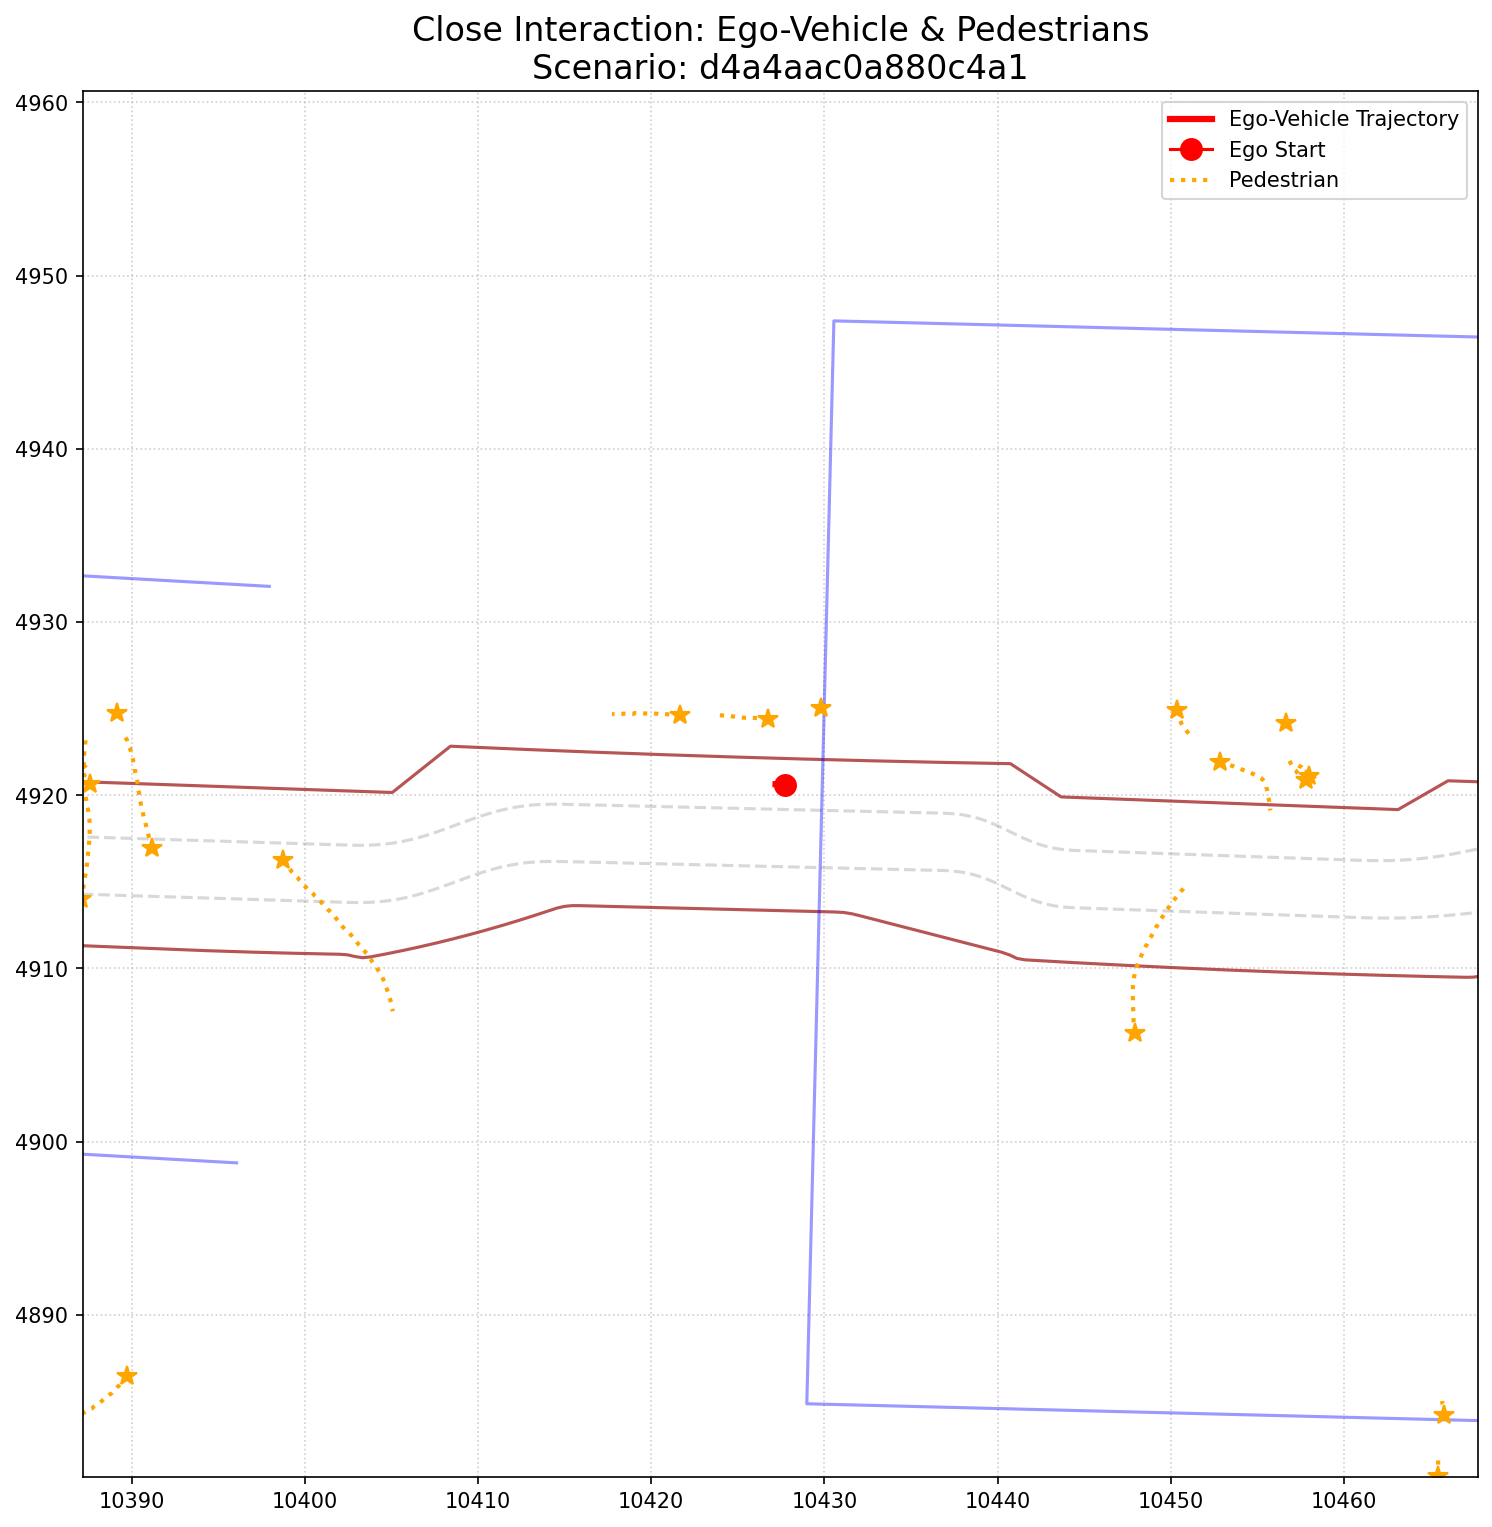

In [2]:
import matplotlib
matplotlib.use('Agg') # Bypass Jupyter rendering bugs
import matplotlib.pyplot as plt
import tensorflow as tf
import glob
from IPython.display import Image, display
from waymo_open_dataset.protos import scenario_pb2

# 1. Target the specific scenario you found!
TARGET_SCENARIO_ID = 'd4a4aac0a880c4a1' 

# 2. Load the dataset again
file_pattern = 'validation.tfrecord-*-of-00150'
file_paths = sorted(glob.glob(file_pattern))[:50]
dataset = tf.data.TFRecordDataset(file_paths)

print(f"Hunting for Scenario {TARGET_SCENARIO_ID}...")

target_scenario = None
for data in dataset.take(200):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    if scenario.scenario_id == TARGET_SCENARIO_ID:
        target_scenario = scenario
        print("✅ Scenario Found! Generating Map...")
        break

if target_scenario:
    # 3. Set up the Canvas
    plt.figure(figsize=(12, 12))
    plt.title(f"Close Interaction: Ego-Vehicle & Pedestrians\nScenario: {target_scenario.scenario_id}", fontsize=16)

    # 4. Draw the Map Features
    for feature in target_scenario.map_features:
        feature_type = feature.WhichOneof("feature_data")
        if feature_type == 'lane':
            pts = feature.lane.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '--', color='gray', alpha=0.3)
        elif feature_type == 'road_line':
            pts = feature.road_line.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='black', alpha=0.5)
        elif feature_type == 'road_edge':
            pts = feature.road_edge.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='brown', alpha=0.8)
        elif feature_type == 'crosswalk':
            pts = feature.crosswalk.polygon
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='blue', alpha=0.4)

    # 5. Draw the Ego-Vehicle (Red)
    ego = target_scenario.tracks[target_scenario.sdc_track_index]
    ego_x = [s.center_x for s in ego.states if s.valid]
    ego_y = [s.center_y for s in ego.states if s.valid]
    plt.plot(ego_x, ego_y, color='red', linewidth=3, label='Ego-Vehicle Trajectory')
    plt.plot(ego_x[0], ego_y[0], color='red', marker='o', markersize=10, label='Ego Start')

    # 6. Draw Pedestrians (Orange)
    pedestrians = [t for t in target_scenario.tracks if t.object_type == 2]
    for i, ped in enumerate(pedestrians):
        ped_x = [s.center_x for s in ped.states if s.valid]
        ped_y = [s.center_y for s in ped.states if s.valid]
        if len(ped_x) > 0:
            label = 'Pedestrian' if i == 0 else "" # Only label the first one for the legend
            plt.plot(ped_x, ped_y, color='orange', linewidth=2, linestyle=':', label=label)
            plt.plot(ped_x[0], ped_y[0], color='orange', marker='*', markersize=10)

    # 7. Format and Save
    plt.axis('equal')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Zoom in around the Ego vehicle to see the interaction clearly
    plt.xlim(min(ego_x) - 40, max(ego_x) + 40)
    plt.ylim(min(ego_y) - 40, max(ego_y) + 40)

    plt.savefig('close_interaction.png', dpi=150, bbox_inches='tight')
    plt.close()

    display(Image('close_interaction.png'))
else:
    print("Scenario not found in the first 200 records.")

Step 1 & 3: Analyzing Speed and Relational Positioning...


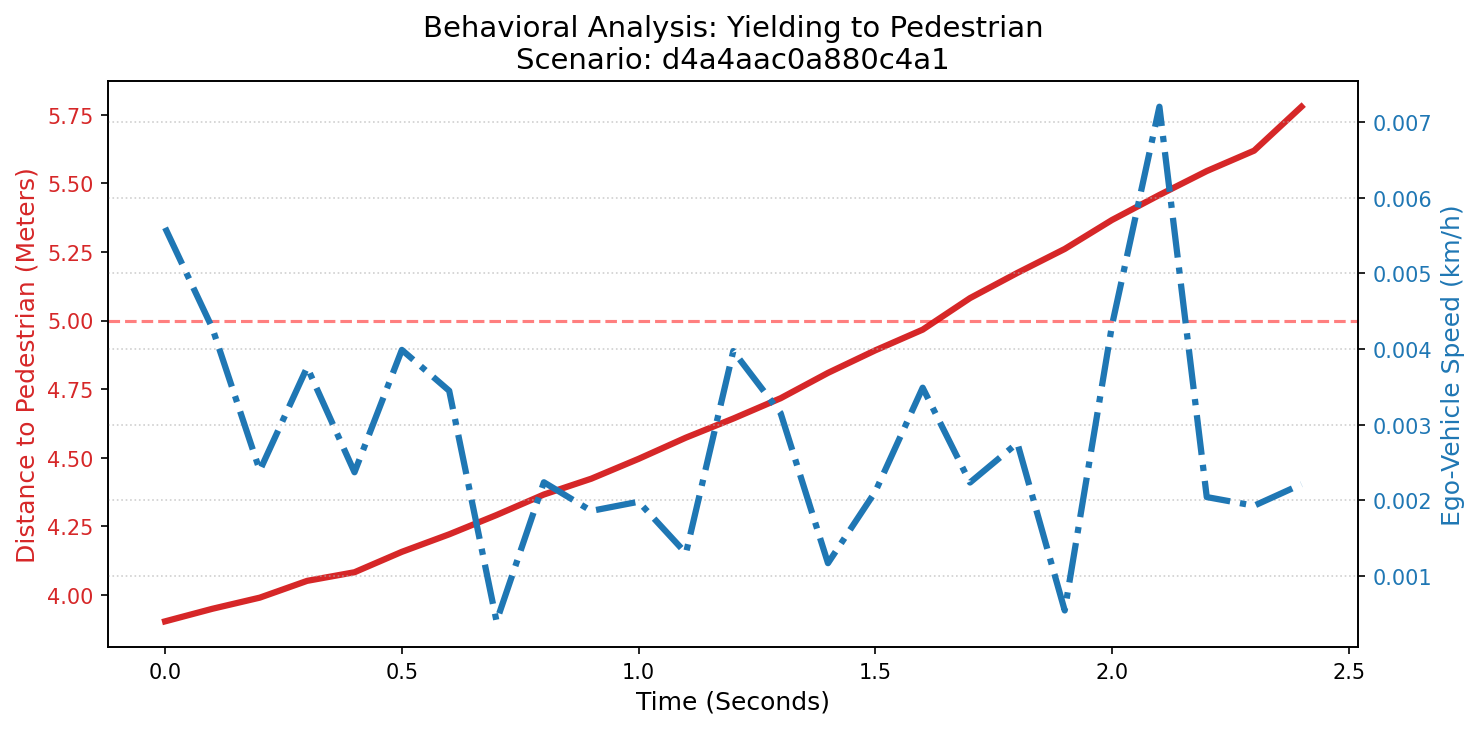

In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import math
from IPython.display import Image, display

print("Step 1 & 3: Analyzing Speed and Relational Positioning...")

ego_vehicle = target_scenario.tracks[target_scenario.sdc_track_index]
pedestrians = [t for t in target_scenario.tracks if t.object_type == 2]

closest_pedestrian = None
min_dist_overall = 1000.0

for ped in pedestrians:
    for step in range(91):
        if ego_vehicle.states[step].valid and ped.states[step].valid:
            dist = math.hypot(ego_vehicle.states[step].center_x - ped.states[step].center_x, 
                              ego_vehicle.states[step].center_y - ped.states[step].center_y)
            if dist < min_dist_overall:
                min_dist_overall = dist
                closest_pedestrian = ped

time_axis = []
ego_speeds = []
distances_to_ped = []

for step in range(91):
    ego_state = ego_vehicle.states[step]
    ped_state = closest_pedestrian.states[step]
    
    if ego_state.valid and ped_state.valid:
        time_axis.append(step * 0.1)
        
        speed_ms = math.hypot(ego_state.velocity_x, ego_state.velocity_y)
        speed_kmh = speed_ms * 3.6 # تبدیل متر بر ثانیه به کیلومتر بر ساعت
        ego_speeds.append(speed_kmh)
        
        distance = math.hypot(ego_state.center_x - ped_state.center_x, 
                              ego_state.center_y - ped_state.center_y)
        distances_to_ped.append(distance)

fig, ax1 = plt.subplots(figsize=(10, 5))
plt.title(f"Behavioral Analysis: Yielding to Pedestrian\nScenario: {target_scenario.scenario_id}", fontsize=14)

color = 'tab:red'
ax1.set_xlabel('Time (Seconds)', fontsize=12)
ax1.set_ylabel('Distance to Pedestrian (Meters)', color=color, fontsize=12)
ax1.plot(time_axis, distances_to_ped, color=color, linewidth=3, label='Distance (m)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(y=5.0, color='red', linestyle='--', alpha=0.5, label='Danger Zone (< 5m)')

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Ego-Vehicle Speed (km/h)', color=color, fontsize=12)
ax2.plot(time_axis, ego_speeds, color=color, linewidth=3, linestyle='-.', label='Speed (km/h)')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('behavior_analysis.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image('behavior_analysis.png'))

Hunting for a complex intersection (searching up to 2000 scenarios)...
✅ Complex Intersection Found at scenario #2!
   -> Scenario ID: 4d82fec943ddaa44
   -> Features: 0 Crosswalks, 7 Stop Signs.


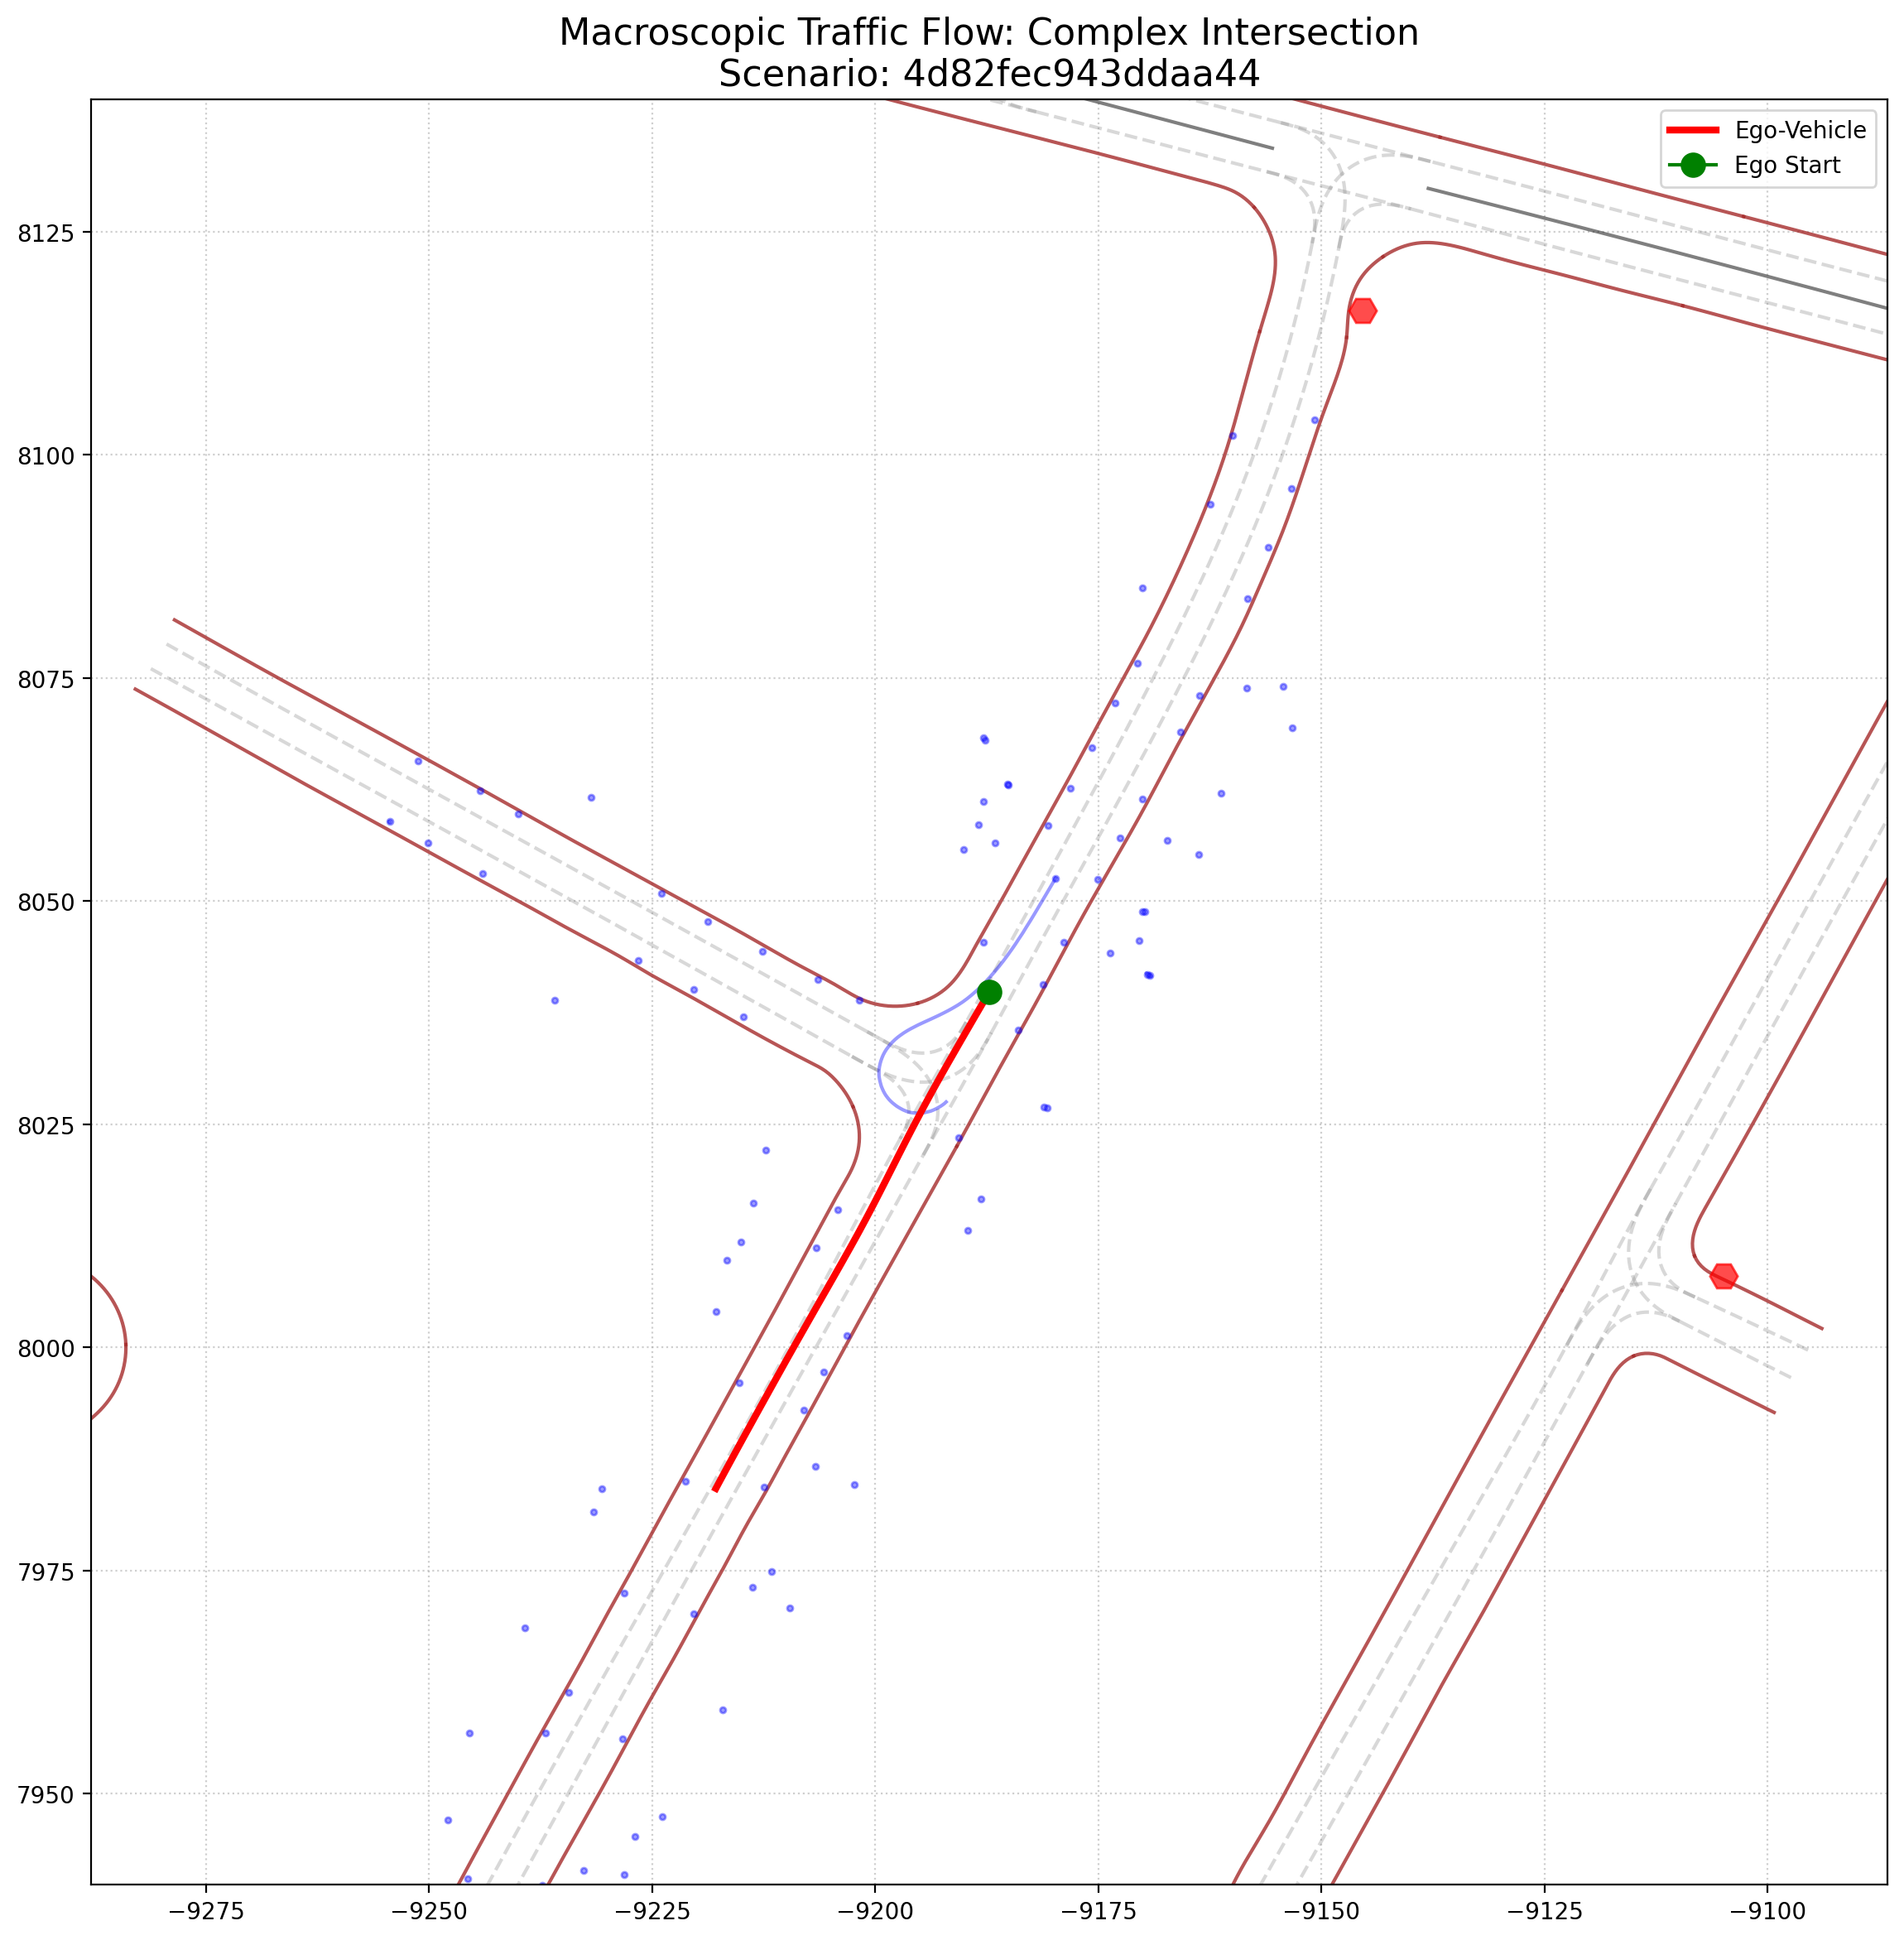

In [4]:
import matplotlib
matplotlib.use('Agg') # Bypass Jupyter rendering bugs
import matplotlib.pyplot as plt
import tensorflow as tf
import glob
from IPython.display import Image, display
from waymo_open_dataset.protos import scenario_pb2

# 1. Load the dataset
file_pattern = 'validation.tfrecord-*-of-00150'
file_paths = sorted(glob.glob(file_pattern))[:50]
dataset = tf.data.TFRecordDataset(file_paths)

print("Hunting for a complex intersection (searching up to 2000 scenarios)...")

target_scenario = None
scenarios_checked = 0

# 2. The Search Algorithm
for data in dataset.take(2000):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    scenarios_checked += 1
    
    crosswalk_count = 0
    stop_sign_count = 0
    
    # Check the map features of this specific scenario
    for feature in scenario.map_features:
        feat_type = feature.WhichOneof("feature_data")
        if feat_type == 'crosswalk':
            crosswalk_count += 1
        elif feat_type == 'stop_sign':
            stop_sign_count += 1
            
    # Our definition of "Complex": At least 3 crosswalks OR 4 stop signs
    if crosswalk_count >= 3 or stop_sign_count >= 4:
        target_scenario = scenario
        print(f"✅ Complex Intersection Found at scenario #{scenarios_checked}!")
        print(f"   -> Scenario ID: {scenario.scenario_id}")
        print(f"   -> Features: {crosswalk_count} Crosswalks, {stop_sign_count} Stop Signs.")
        break

# 3. The Plotting Pipeline
if target_scenario:
    plt.figure(figsize=(14, 14))
    plt.title(f"Macroscopic Traffic Flow: Complex Intersection\nScenario: {target_scenario.scenario_id}", fontsize=16)

    # A. Draw the Map
    for feature in target_scenario.map_features:
        feat_type = feature.WhichOneof("feature_data")
        if feat_type == 'lane':
            pts = feature.lane.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '--', color='gray', alpha=0.3)
        elif feat_type == 'road_line':
            pts = feature.road_line.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='black', alpha=0.5)
        elif feat_type == 'road_edge':
            pts = feature.road_edge.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='brown', alpha=0.8)
        elif feat_type == 'crosswalk':
            pts = feature.crosswalk.polygon
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='blue', alpha=0.2)
        elif feat_type == 'stop_sign':
            # Mark stop signs with a big red octagon
            pos = feature.stop_sign.position
            plt.plot(pos.x, pos.y, marker='H', color='red', markersize=12, alpha=0.7)

    # B. Draw ALL other vehicles (Blue) to see traffic flow
    for track in target_scenario.tracks:
        if track.object_type == 1: # 1 = Vehicle
            veh_x = [s.center_x for s in track.states if s.valid]
            veh_y = [s.center_y for s in track.states if s.valid]
            if len(veh_x) > 0:
                plt.plot(veh_x, veh_y, color='blue', linewidth=1.5, alpha=0.4)
                plt.plot(veh_x[0], veh_y[0], color='blue', marker='.', markersize=5, alpha=0.4) # Start point

    # C. Draw the Ego-Vehicle (Red) so it stands out
    ego = target_scenario.tracks[target_scenario.sdc_track_index]
    ego_x = [s.center_x for s in ego.states if s.valid]
    ego_y = [s.center_y for s in ego.states if s.valid]
    plt.plot(ego_x, ego_y, color='red', linewidth=3, label='Ego-Vehicle')
    plt.plot(ego_x[0], ego_y[0], color='green', marker='o', markersize=10, label='Ego Start')

    # D. Format and Save
    plt.axis('equal')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Center the camera on the Ego vehicle but keep a wide view (100 meters in each direction)
    plt.xlim(ego_x[0] - 100, ego_x[0] + 100)
    plt.ylim(ego_y[0] - 100, ego_y[0] + 100)

    plt.savefig('complex_intersection.png', dpi=200, bbox_inches='tight')
    plt.close()

    display(Image('complex_intersection.png'))
else:
    print("Could not find a complex intersection in the first 2000 scenarios. Try increasing the search limit!")

In [1]:
import tensorflow as tf
import glob
from waymo_open_dataset.protos import scenario_pb2

# 1. Load one file and grab the very first scenario
file_pattern = 'validation.tfrecord-00000-of-00150'
dataset = tf.data.TFRecordDataset(file_pattern)

for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    print(f"=== SCENARIO METADATA ===")
    print(f"ID: {scenario.scenario_id}")
    print(f"Time steps: {len(scenario.timestamps_seconds)} (Each step is 0.1s)")
    print(f"Total Agents (Tracks): {len(scenario.tracks)}")
    print(f"Total Map Features: {len(scenario.map_features)}")
    print(f"Total Traffic Light States: {len(scenario.dynamic_map_states)}")
    
    print("\n=== AGENT (TRACK) PARAMETERS ===")
    sample_agent = scenario.tracks[0]
    print(f"Agent Type: {sample_agent.object_type} (1=Vehicle, 2=Pedestrian, 3=Cyclist)")
    print(f"Agent ID: {sample_agent.id}")
    
    print("\n=== EXACT KINEMATIC FEATURES (At Time Step 0) ===")
    sample_state = sample_agent.states[0]
    # We use dir() to dynamically pull all available attributes in the protobuf object
    available_features = [f for f in dir(sample_state) if not f.startswith('_')]
    
    for feature in available_features:
        try:
            value = getattr(sample_state, feature)
            if isinstance(value, (int, float, bool)):
                print(f" - {feature}: {value}")
        except:
            pass

2026-04-13 11:26:20.393714: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 11:26:20.445785: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 11:26:20.447603: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-13 11:26:20.447610: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudar

=== SCENARIO METADATA ===
ID: b85e1bd6cc8e74c0
Time steps: 91 (Each step is 0.1s)
Total Agents (Tracks): 14
Total Map Features: 139
Total Traffic Light States: 91

=== AGENT (TRACK) PARAMETERS ===
Agent Type: 1 (1=Vehicle, 2=Pedestrian, 3=Cyclist)
Agent ID: 1807

=== EXACT KINEMATIC FEATURES (At Time Step 0) ===
 - center_x: 3578.34912109375
 - center_y: 4986.5380859375
 - center_z: 31.326579674761483
 - heading: -1.5208313465118408
 - height: 1.691864013671875
 - length: 4.763912200927734
 - valid: True
 - velocity_x: 1.08642578125
 - velocity_y: -21.40625
 - width: 2.0494463443756104


2026-04-13 11:26:21.296870: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-13 11:26:21.298140: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-13 11:26:21.298172: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-04-13 11:26:21.298215: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-04-13 11:26:21.298235: W tensorflow/c

Starting the Dataset Census (Analyzing up to 20000 scenarios)...
------------------------------
Total Scenarios Analyzed: 14717
Average Vehicles per Scenario: 59.3
Max Vehicles in one Scenario: 385
Average Pedestrians per Scenario: 7.5
Max Pedestrians in one Scenario: 322
------------------------------


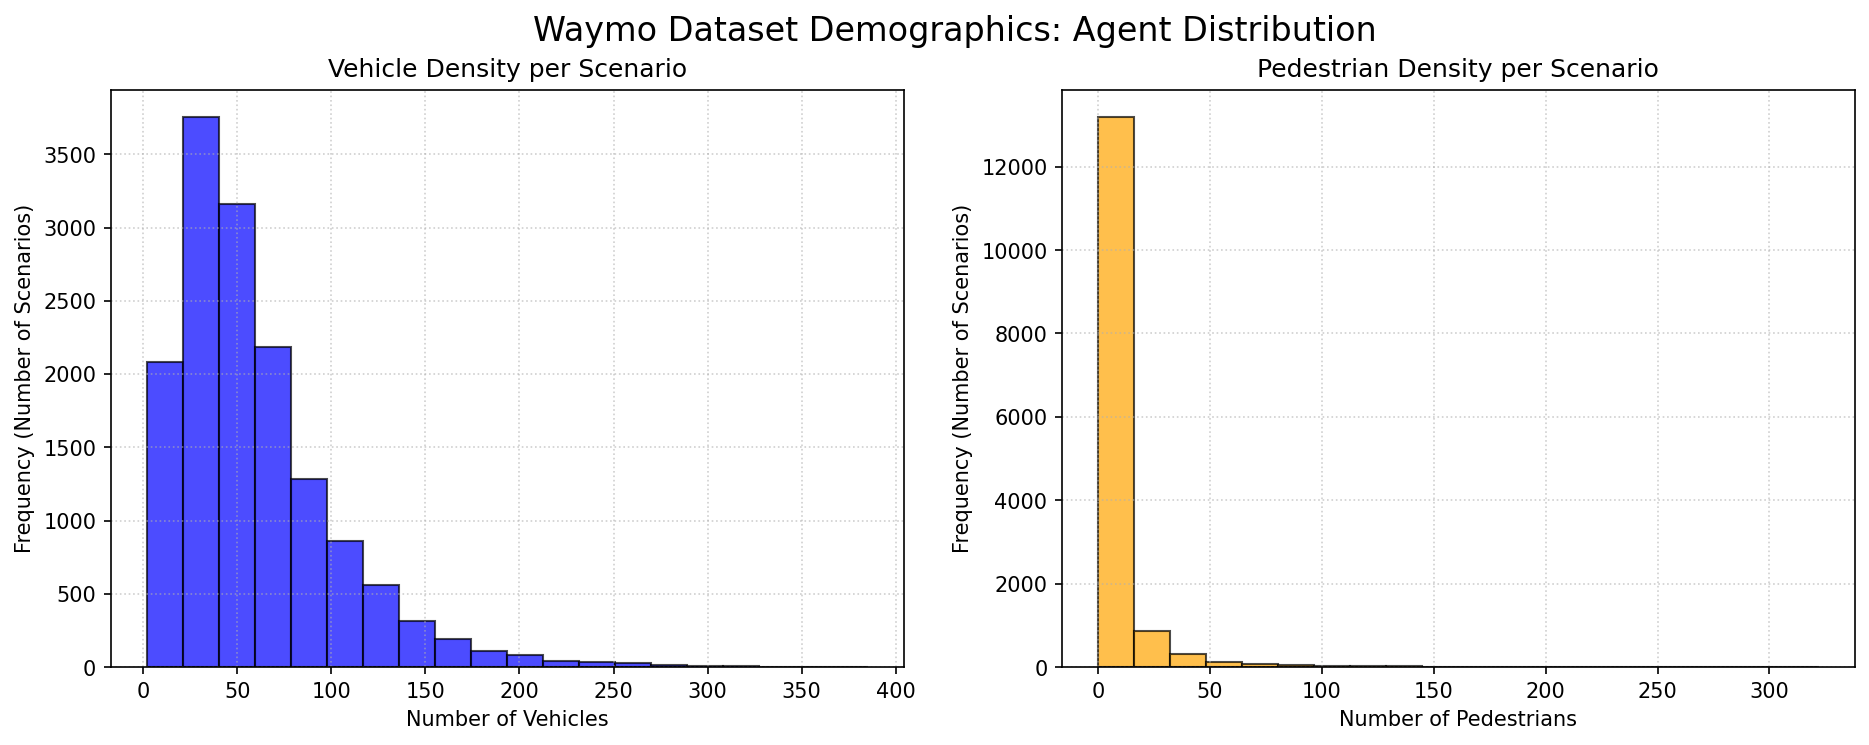

In [5]:
import matplotlib
matplotlib.use('Agg') # Safe headless backend
import matplotlib.pyplot as plt
import tensorflow as tf
import glob
import numpy as np
from waymo_open_dataset.protos import scenario_pb2
from IPython.display import Image, display

print("Starting the Dataset Census (Analyzing up to 20000 scenarios)...")

# 1. Load the dataset files
file_pattern = 'validation.tfrecord-*-of-00150'
file_paths = sorted(glob.glob(file_pattern))[:50]
dataset = tf.data.TFRecordDataset(file_paths)

# Lists to store our statistical counts for each scenario
vehicle_counts = []
pedestrian_counts = []
cyclist_counts = []

scenarios_analyzed = 0

# 2. Extract Data (The "Census" Loop)
for data in dataset.take(20000):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    scenarios_analyzed += 1
    
    v_count = 0
    p_count = 0
    c_count = 0
    
    # Check every agent (track) in the scenario
    for track in scenario.tracks:
        if track.object_type == 1:   # TYPE_VEHICLE
            v_count += 1
        elif track.object_type == 2: # TYPE_PEDESTRIAN
            p_count += 1
        elif track.object_type == 3: # TYPE_CYCLIST
            c_count += 1
            
    vehicle_counts.append(v_count)
    pedestrian_counts.append(p_count)
    cyclist_counts.append(c_count)

# 3. Print the Summary Statistics for your Thesis
print("-" * 30)
print(f"Total Scenarios Analyzed: {scenarios_analyzed}")
print(f"Average Vehicles per Scenario: {np.mean(vehicle_counts):.1f}")
print(f"Max Vehicles in one Scenario: {np.max(vehicle_counts)}")
print(f"Average Pedestrians per Scenario: {np.mean(pedestrian_counts):.1f}")
print(f"Max Pedestrians in one Scenario: {np.max(pedestrian_counts)}")
print("-" * 30)

# 4. Generate the Visualization Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Waymo Dataset Demographics: Agent Distribution", fontsize=16)

# Chart 1: Vehicle Density Distribution
ax1.hist(vehicle_counts, bins=20, color='blue', alpha=0.7, edgecolor='black')
ax1.set_title("Vehicle Density per Scenario")
ax1.set_xlabel("Number of Vehicles")
ax1.set_ylabel("Frequency (Number of Scenarios)")
ax1.grid(True, linestyle=':', alpha=0.6)

# Chart 2: Pedestrian Density Distribution
ax2.hist(pedestrian_counts, bins=20, color='orange', alpha=0.7, edgecolor='black')
ax2.set_title("Pedestrian Density per Scenario")
ax2.set_xlabel("Number of Pedestrians")
ax2.set_ylabel("Frequency (Number of Scenarios)")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.savefig('dataset_census.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image('dataset_census.png'))

Starting the Behavioral Motion Labeler...


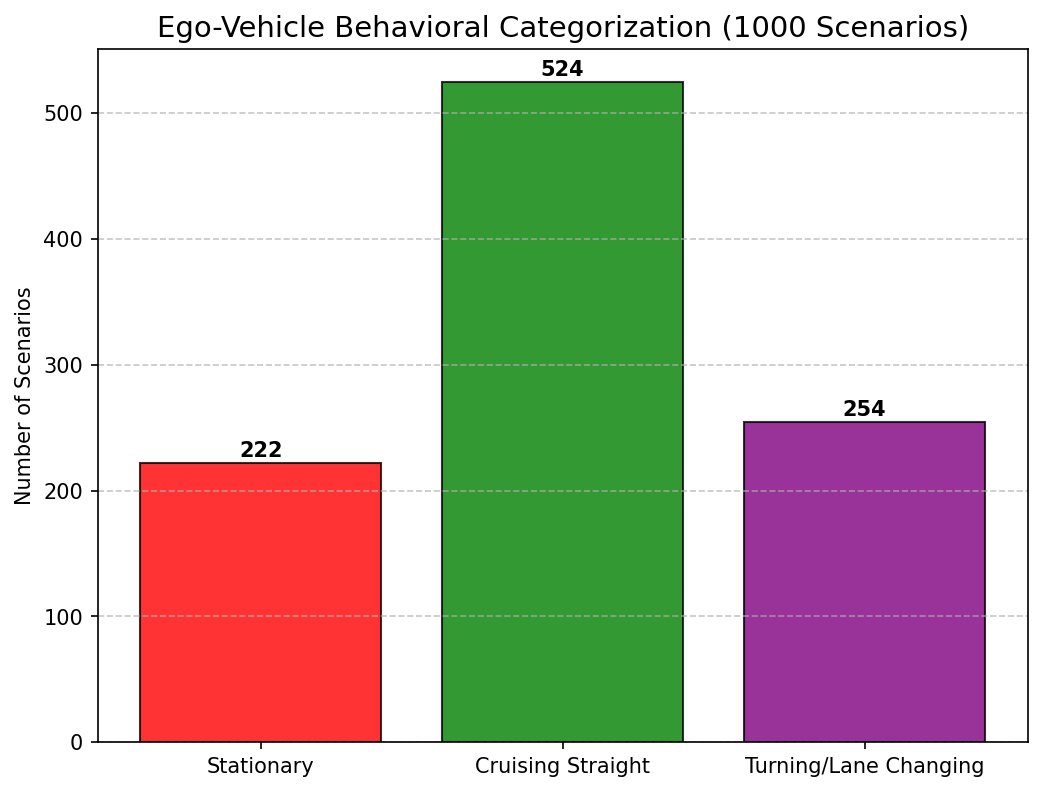

In [3]:
import math
import numpy as np

print("Starting the Behavioral Motion Labeler...")

behavior_labels = {"Stationary": 0, "Cruising Straight": 0, "Turning/Lane Changing": 0}

for data in dataset.take(20000):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    # 1. Isolate the Ego-Vehicle
    ego = scenario.tracks[scenario.sdc_track_index]
    
    speeds = []
    headings = []
    
    # 2. Extract kinematics for the 9-second window
    for state in ego.states:
        if state.valid:
            # Calculate absolute speed (m/s)
            speed = math.hypot(state.velocity_x, state.velocity_y)
            speeds.append(speed)
            # Store the heading (angle)
            headings.append(state.heading)
            
    # If we have missing data, skip this scenario
    if len(speeds) < 10:
        continue
        
    # 3. The Labeling Logic (Rule-Based Classification)
    max_speed = np.max(speeds)
    
    # Calculate how much the car rotated (Max angle - Min angle)
    heading_variance = np.max(headings) - np.min(headings)
    
    if max_speed < 1.0: # Less than 1 m/s max speed
        behavior_labels["Stationary"] += 1
    elif heading_variance > 0.15: # Rotated more than ~8.5 degrees
        behavior_labels["Turning/Lane Changing"] += 1
    else:
        behavior_labels["Cruising Straight"] += 1

# 4. Plot the Categorized Behaviors
labels = list(behavior_labels.keys())
counts = list(behavior_labels.values())

plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color=['red', 'green', 'purple'], alpha=0.8, edgecolor='black')
plt.title("Ego-Vehicle Behavioral Categorization (1000 Scenarios)", fontsize=14)
plt.ylabel("Number of Scenarios")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact numbers on top of the bars
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.savefig('behavior_labels.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image('behavior_labels.png'))

In [6]:
import tensorflow as tf

print("=== GPU Check ===")
gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

if len(gpus) > 0:
    for gpu in gpus:
        print(f"GPU Details: {gpu}")
else:
    print("TensorFlow is still only seeing the CPU!")

=== GPU Check ===
Num GPUs Available: 0
TensorFlow is still only seeing the CPU!


In [1]:
import tensorflow as tf

print("=== GPU Check ===")
gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

if len(gpus) > 0:
    for gpu in gpus:
        print(f"✅ GPU Details: {gpu}")
else:
    print("❌ TensorFlow is still only seeing the CPU!")

2026-04-13 19:42:09.893990: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 19:42:09.949921: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 19:42:09.951666: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-13 19:42:09.951674: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudar

=== GPU Check ===
Num GPUs Available: 0
❌ TensorFlow is still only seeing the CPU!


2026-04-13 19:42:10.820539: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-13 19:42:10.821813: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-13 19:42:10.821844: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-04-13 19:42:10.821865: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-04-13 19:42:10.821885: W tensorflow/c

Running Ego-Centric Normalization...
Original Ego Position: X=3581.41, Y=4977.78, Heading=-1.57 rad


2026-04-13 20:45:19.605387: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 20:45:19.606282: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-13 20:45:19.608978: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-13 20:45:19.609866: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at

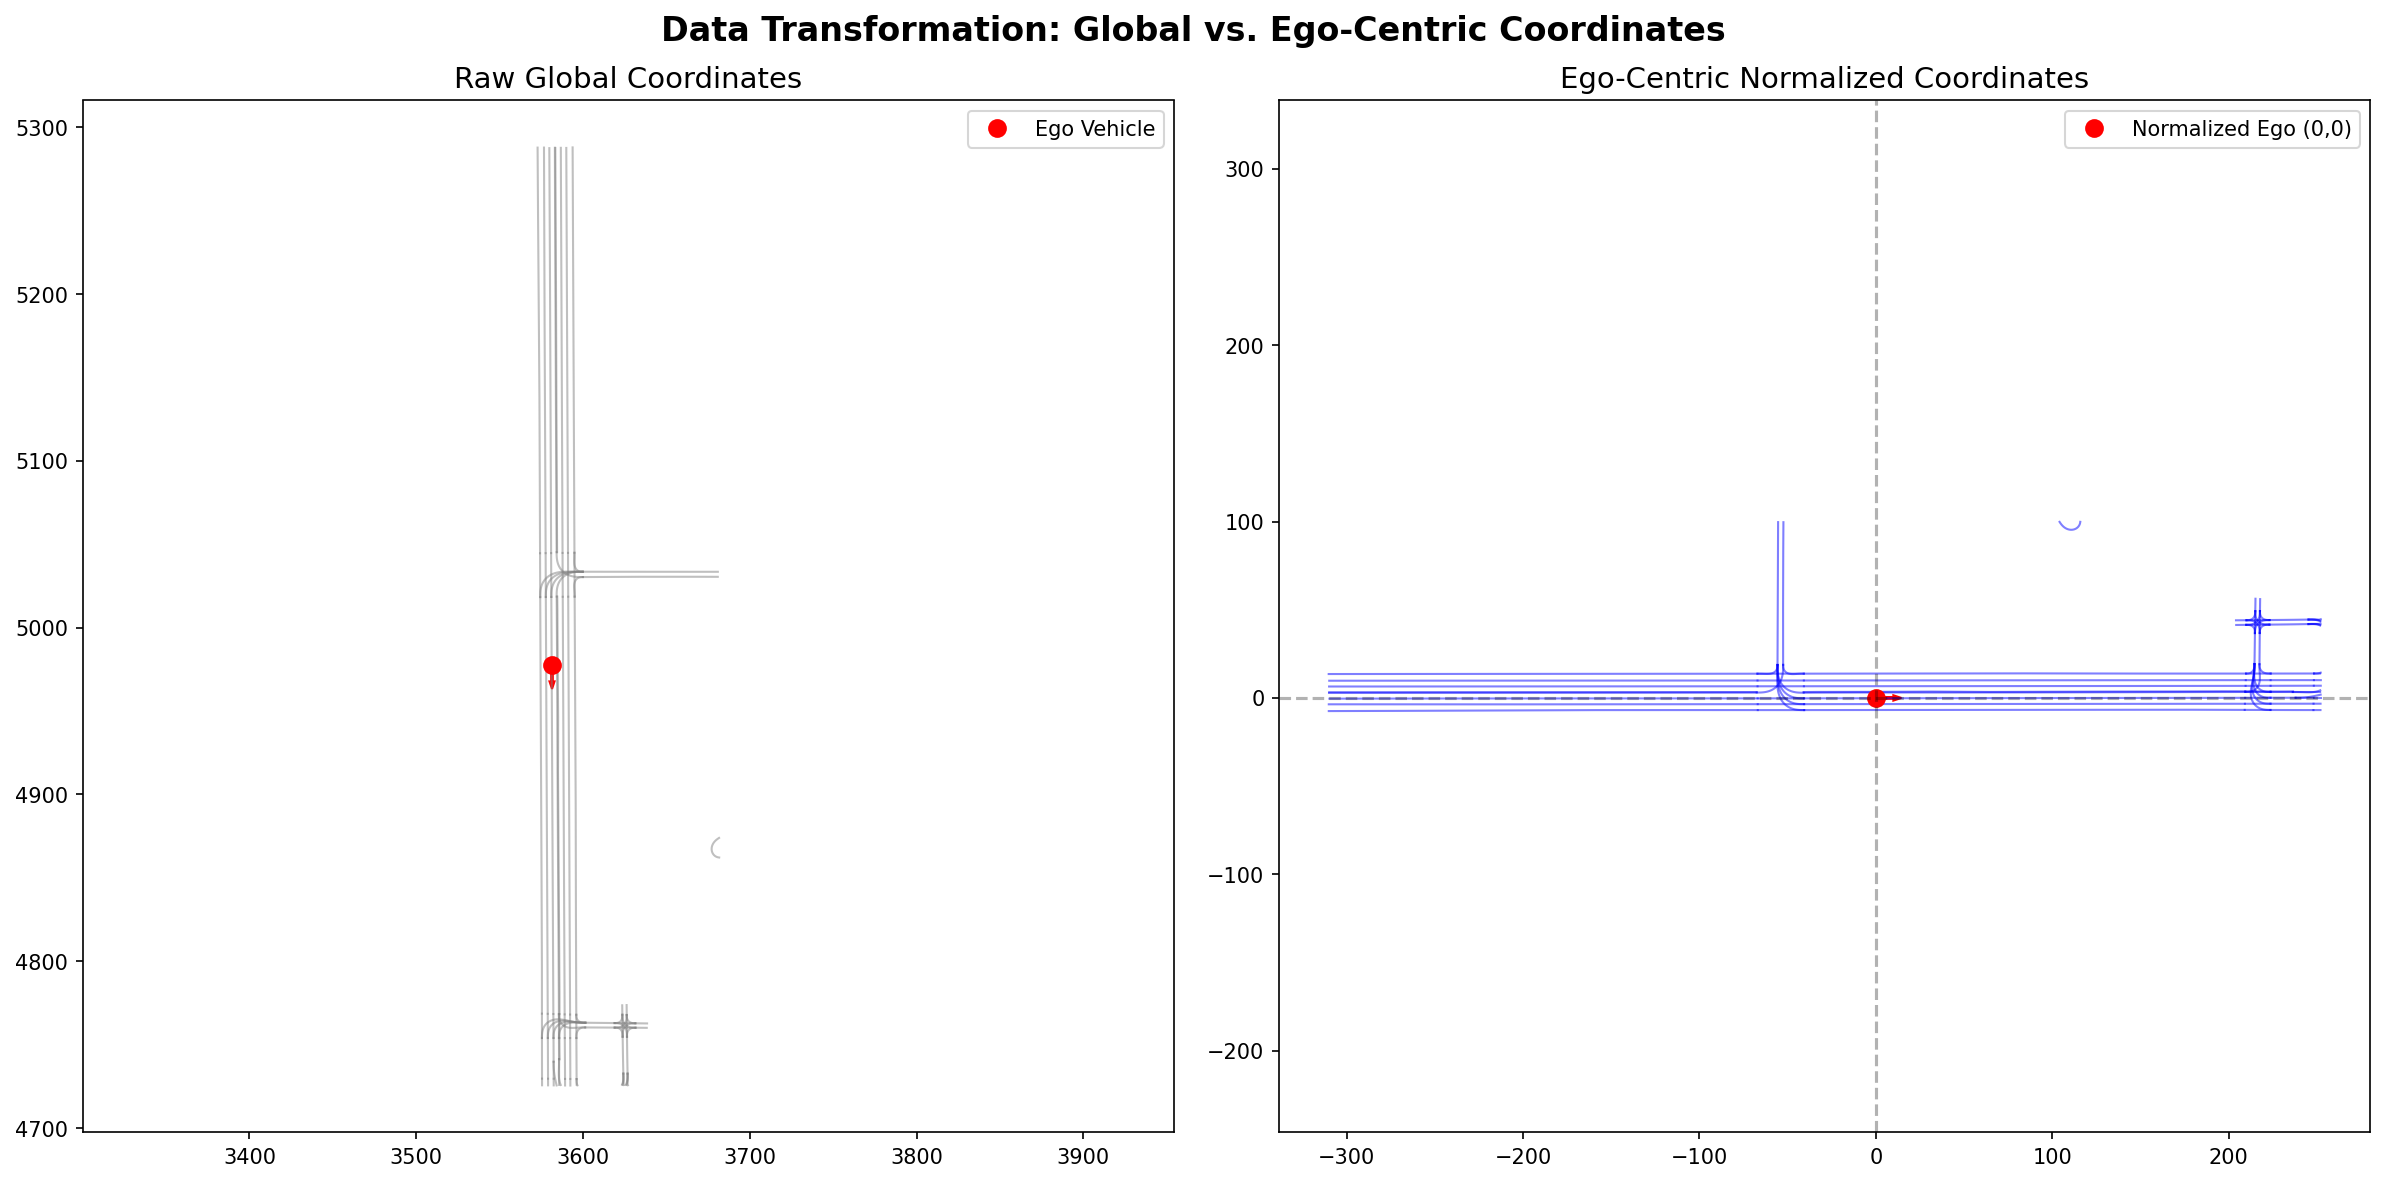

In [2]:
import tensorflow as tf
import numpy as np
import math
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from waymo_open_dataset.protos import scenario_pb2
from IPython.display import Image, display
import glob

print("Running Ego-Centric Normalization...")

# 1. Load a single scenario
file_pattern = 'validation.tfrecord-*-of-00150'
file_paths = sorted(glob.glob(file_pattern))[:1]
dataset = tf.data.TFRecordDataset(file_paths)

for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    # 2. Get the Ego-Vehicle's exact state at Time Step 10 (Current Time)
    ego_track = scenario.tracks[scenario.sdc_track_index]
    ego_state = ego_track.states[10] # State at current time
    
    ego_x = ego_state.center_x
    ego_y = ego_state.center_y
    # Waymo heading: 0 is positive X. We want to rotate by negative heading to face X=0.
    ego_heading = ego_state.heading 
    
    print(f"Original Ego Position: X={ego_x:.2f}, Y={ego_y:.2f}, Heading={ego_heading:.2f} rad")

    # 3. Create the Rotation Matrix function
    def normalize_point(x, y, ego_x, ego_y, ego_heading):
        # Translate to origin
        dx = x - ego_x
        dy = y - ego_y
        # Rotate by -heading
        cos_h = math.cos(-ego_heading)
        sin_h = math.sin(-ego_heading)
        
        norm_x = dx * cos_h - dy * sin_h
        norm_y = dx * sin_h + dy * cos_h
        return norm_x, norm_y

    # 4. Set up the Before & After Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle("Data Transformation: Global vs. Ego-Centric Coordinates", fontsize=16, fontweight='bold')

    # 5. Extract and Plot Map Features
    for feature in scenario.map_features:
        if feature.HasField('lane'):
            # RAW GLOBAL PLOT (Left)
            global_x = [pt.x for pt in feature.lane.polyline]
            global_y = [pt.y for pt in feature.lane.polyline]
            ax1.plot(global_x, global_y, color='gray', linewidth=1, alpha=0.5)
            
            # NORMALIZED PLOT (Right)
            norm_points = [normalize_point(pt.x, pt.y, ego_x, ego_y, ego_heading) for pt in feature.lane.polyline]
            norm_x = [p[0] for p in norm_points]
            norm_y = [p[1] for p in norm_points]
            ax2.plot(norm_x, norm_y, color='blue', linewidth=1, alpha=0.5)

    # 6. Plot the Ego Vehicle
    # Raw
    ax1.plot(ego_x, ego_y, 'ro', markersize=8, label='Ego Vehicle')
    ax1.arrow(ego_x, ego_y, math.cos(ego_heading)*10, math.sin(ego_heading)*10, color='red', width=1)
    ax1.set_title("Raw Global Coordinates", fontsize=14)
    ax1.axis('equal')
    ax1.legend()

    # Normalized (Should be exactly at 0,0 facing straight right on the X-axis)
    ax2.plot(0, 0, 'ro', markersize=8, label='Normalized Ego (0,0)')
    ax2.arrow(0, 0, 10, 0, color='red', width=1) # Arrow pointing straight along X axis
    ax2.set_title("Ego-Centric Normalized Coordinates", fontsize=14)
    ax2.axis('equal')
    ax2.legend()
    
    # Add a crosshair at 0,0 for visual proof
    ax2.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax2.axvline(0, color='black', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('ego_centric_normalization.png', dpi=150, bbox_inches='tight')
    plt.close()

display(Image('ego_centric_normalization.png'))

In [ ]:
import tensorflow as tf
import numpy as np
import math
import glob
from waymo_open_dataset.protos import scenario_pb2
import os

print("Building Deep Learning Tensors...")

# --- Hyperparameters for the Tensor ---
MAX_AGENTS = 64
TIME_STEPS = 91
FEATURES = 6  # [X, Y, Vel_X, Vel_Y, Type, Valid_Mask]

# 1. Load a scenario
file_pattern = 'validation.tfrecord-*-of-00150'
file_paths = sorted(glob.glob(file_pattern))[:1]
dataset = tf.data.TFRecordDataset(file_paths)

for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    # 2. Get Ego-Vehicle's Reference Frame at Time Step 10 (Current Time)
    ego_track = scenario.tracks[scenario.sdc_track_index]
    ego_state = ego_track.states[10]
    
    ref_x = ego_state.center_x
    ref_y = ego_state.center_y
    ref_heading = ego_state.heading
    
    cos_h = math.cos(-ref_heading)
    sin_h = math.sin(-ref_heading)

    # 3. Initialize the Empty Tensor with Zeros (Padding)
    # Shape: [64, 91, 6]
    scenario_tensor = np.zeros((MAX_AGENTS, TIME_STEPS, FEATURES), dtype=np.float32)
    
    # 4. Extract and Populate the Tensor
    # We always put the Ego-Vehicle at Index 0!
    valid_tracks = [ego_track] + [t for i, t in enumerate(scenario.tracks) if i != scenario.sdc_track_index]
    
    # Truncate if there are more than MAX_AGENTS
    valid_tracks = valid_tracks[:MAX_AGENTS]
    
    for agent_idx, track in enumerate(valid_tracks):
        agent_type = track.object_type # 1: Vehicle, 2: Pedestrian, 3: Cyclist
        
        for t_idx, state in enumerate(track.states):
            if t_idx >= TIME_STEPS:
                break
                
            if state.valid: # If the sensor actually saw the agent at this millisecond
                # A. Translate to Ego-Origin
                dx = state.center_x - ref_x
                dy = state.center_y - ref_y
                
                # B. Rotate Position
                norm_x = dx * cos_h - dy * sin_h
                norm_y = dx * sin_h + dy * cos_h
                
                # C. Rotate Velocity (Velocities are vectors, so they must rotate too!)
                vx = state.velocity_x
                vy = state.velocity_y
                norm_vx = vx * cos_h - vy * sin_h
                norm_vy = vx * sin_h + vy * cos_h
                
                # D. Store in Tensor
                scenario_tensor[agent_idx, t_idx, 0] = norm_x
                scenario_tensor[agent_idx, t_idx, 1] = norm_y
                scenario_tensor[agent_idx, t_idx, 2] = norm_vx
                scenario_tensor[agent_idx, t_idx, 3] = norm_vy
                scenario_tensor[agent_idx, t_idx, 4] = float(agent_type)
                scenario_tensor[agent_idx, t_idx, 5] = 1.0 # Valid Mask = TRUE
                
    # 5. Convert the Numpy Array to a native TensorFlow Tensor
    final_tf_tensor = tf.convert_to_tensor(scenario_tensor, dtype=tf.float32)
    
    print("-" * 40)
    print("✅ SCENARIO TENSOR CREATED SUCCESSFULLY")
    print(f"Final Tensor Shape: {final_tf_tensor.shape}")
    print(f"Data Type: {final_tf_tensor.dtype}")
    print("-" * 40)
    
    # Let's prove it worked by checking the Ego-vehicle (Agent 0) at Time Step 10
    print("\n🔍 Proof of Normalization (Ego at Step 10):")
    ego_t10 = final_tf_tensor[0, 10, :].numpy()
    print(f"X position: {ego_t10[0]:.4f} (Should be 0.0)")
    print(f"Y position: {ego_t10[1]:.4f} (Should be 0.0)")
    print(f"Agent Type: {ego_t10[4]} (1.0 = Vehicle)")
    print(f"Valid Mask: {ego_t10[5]} (1.0 = Data Exists)")

    
    

# Create a folder to store your processed training data
save_dir = "processed_tensors"
os.makedirs(save_dir, exist_ok=True)

# Save the tensor to disk
save_path = os.path.join(save_dir, "scenario_0001.npy")
np.save(save_path, final_tf_tensor.numpy())

print(f"💾 Tensor saved permanently to: {save_path}")

Building Deep Learning Tensors...
----------------------------------------
✅ SCENARIO TENSOR CREATED SUCCESSFULLY
Final Tensor Shape: (64, 91, 6)
Data Type: <dtype: 'float32'>
----------------------------------------

🔍 Proof of Normalization (Ego at Step 10):
X position: 0.0000 (Should be 0.0)
Y position: 0.0000 (Should be 0.0)
Agent Type: 1.0 (1.0 = Vehicle)
Valid Mask: 1.0 (1.0 = Data Exists)
